In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
m_values = np.array([2**k for k in range(1, 13)])
a = 1
b = 2
f = lambda x : 1 / np.sqrt(x)
F = lambda x : 2 * np.sqrt(x)
exact = F(b) - F(a)

In [3]:
def estimate_integral(t, h, f):
    I = 0
    for i in range(len(t)):
        I += (h/4) * (3*f(t[i] + h/3) + f(t[i] + h))
    return I

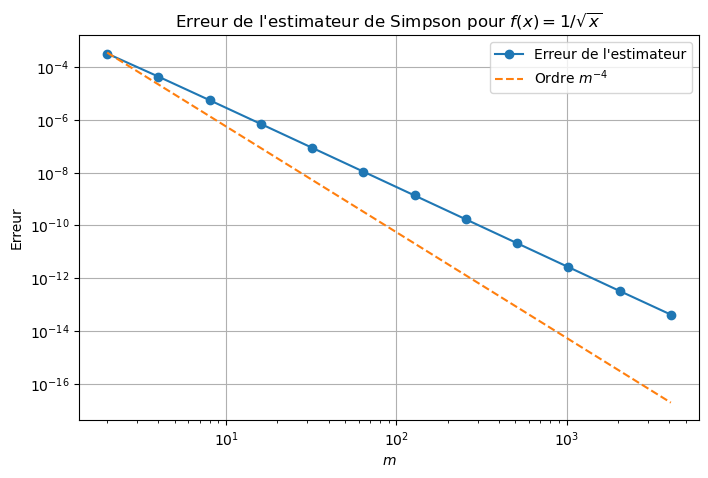

In [4]:
estimate_integrals = []
for m in m_values:
    h = (b-a)/m
    t = np.linspace(a, b, int(m)+1)[:-1]  # points de depart des sous-intervalles
    estimate_integrals.append(estimate_integral(t, h, f))
errors = np.abs(np.array(estimate_integrals) - exact)
plt.figure(figsize=(8, 5))
plt.loglog(m_values, errors, 'o-', label="Erreur de l'estimateur")
plt.loglog(m_values, (b-a)**4 / (180 * m_values**4), '--', label=r'Ordre $m^{-4}$')
plt.xlabel(r'$m$')
plt.ylabel('Erreur')
plt.title(r"Erreur de l'estimateur de Simpson pour $f(x) = 1/\sqrt{x}$")
plt.legend()
plt.grid()
